# <span style="color: darkgreen;">**Beat The Algorithm - Leveraging Machine Learning for Hit Songs**</span>
#### <span style="color: green;">*Group 4 - Sam Jones, Alejandro Osto, Waldo Barreto Tascón, Joaquín Miño, Yeabsira Seleshi*</span>

# 1. Exploratory Data Analysis & Transformation

### 1.1 Data Loading

In [2]:
!pip install openpyxl
import pandas as pd

songsDF = pd.read_excel("Songs_2025.xlsx",sheet_name = 'spotify songs')

### 1.2 Initial Data Exploration

In [3]:
print(f'Shape:\n{songsDF.shape}\n')
print(f'Data Types:\n{songsDF.dtypes}\n')
print(f'Nulls:\n{songsDF.isna().sum()}\n')
(songsDF.describe())

# There are 2300 songs, and 19 variables

# year is an integer between 2000-2022
# track_name, album, artist_name & artist_genres are strings
# track_popularity and artist_popularity are integers between 0-100
# danceability, energy, speechiness, acousticness, instrumentalness, liveness, valence are floats measured from 0-1
# loudness is a float randing from -56 to 132 (dB)
# key & mode are categorical, represented as integers from 0-11 and 0-1 respectively
# Tempo is an integer measured between 60-210 (Beats per Minute)
# duration_ms is an integer, ranging from 97393-688453

Shape:
(2300, 19)

Data Types:
year                   int64
track_name            object
track_popularity       int64
album                 object
artist_name           object
artist_genres         object
artist_popularity      int64
danceability         float64
energy               float64
key                  float64
loudness             float64
mode                 float64
speechiness          float64
acousticness         float64
instrumentalness     float64
liveness             float64
valence              float64
tempo                float64
duration_ms          float64
dtype: object

Nulls:
year                 0
track_name           0
track_popularity     0
album                0
artist_name          0
artist_genres        0
artist_popularity    0
danceability         1
energy               1
key                  1
loudness             1
mode                 1
speechiness          1
acousticness         1
instrumentalness     1
liveness             1
valence              1
tempo

,year,track_popularity,artist_popularity,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,duration_ms
count,2300.000000,2300.000000,2300.000000,2299.000000,2299.000000,2299.000000,2299.000000,2299.000000,2299.000000,2299.000000,2299.000000,2299.000000,2299.000000,2299.000000,2299.000000
mean,2011.000000,70.943478,72.869565,0.660116,0.693047,5.277947,73.006960,0.598521,0.097795,0.157689,0.013766,0.172618,0.535110,120.512450,226033.494128
std,6.634692,12.291526,12.179263,0.141137,0.164838,3.628494,15.643937,0.490304,0.092445,0.203844,0.083990,0.131620,0.227821,27.617729,42063.678588
min,2000.000000,0.000000,29.000000,0.162000,0.051900,0.000000,-56.000000,0.000000,0.022500,0.000013,0.000000,0.021000,0.037700,60.019000,97393.000000
25%,2005.000000,66.000000,65.000000,0.572000,0.586000,2.000000,63.000000,0.000000,0.038000,0.016500,0.000000,0.089950,0.360500,98.569500,200179.500000
50%,2011.000000,72.000000,74.000000,0.671000,0.712000,5.000000,74.000000,1.000000,0.056800,0.068900,0.000000,0.119000,0.540000,120.000000,221653.000000
75%,2017.000000,79.000000,82.000000,0.759500,0.820000,8.000000,83.000000,1.000000,0.115500,0.223000,0.000054,0.220000,0.722000,137.028000,245950.000000
max,2022.000000,100.000000,100.000000,0.975000,0.999000,11.000000,132.000000,1.000000,0.576000,0.978000,0.985000,0.843000,0.974000,210.857000,688453.000000


In [4]:
songsDF[songsDF['danceability'].isna()]

# The song with null values is index 488

,year,track_name,track_popularity,album,artist_name,artist_genres,artist_popularity,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,duration_ms
488,2004,These Words,68,Unwritten,Natasha Bedingfield,['dance pop'; 'pop'; 'post-teen pop'],64,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [5]:
songsDF.groupby('year').size()

# The songs are divided evenly by year, with 100 songs every year from 2000-2022

,0
year,
2000,100
2001,100
2002,100
2003,100
2004,100
2005,100
2006,100
2007,100
2008,100


### 1.3 Data Cleaning

#### 1.3.1 Null Values

In [6]:
songsDF = songsDF.drop(songsDF[songsDF['danceability'].isna()].index[0])

# Deleted the row with null values

#### 1.3.2 Negative Decibel Values

In [7]:
print(songsDF['loudness'].describe())

len(songsDF[songsDF['loudness']<40])

# 43 songs out of 2300 have decibel levels below, which doesn't seem reasonable for music
# We decided to drop the loudness column as we see the other variables as more interesting to the business case

songsDF = songsDF.drop(columns='loudness')

count    2299.000000
mean       73.006960
std        15.643937
min       -56.000000
25%        63.000000
50%        74.000000
75%        83.000000
max       132.000000
Name: loudness, dtype: float64


#### 1.3.3 Data Types

In [8]:
songsDF['duration_ms'] = songsDF['duration_ms'].astype(int)

# Changed dtype to int for 'duration_ms' column

### 1.4 Data Transformation

#### 1.4.1 Artist Genres

In [9]:
import ast

songsDF['artist_genres'] = songsDF['artist_genres'].str.replace(';',',')

def convert_to_list(string_list):
    return ast.literal_eval(string_list)

songsDF['artist_genres'] = songsDF['artist_genres'].apply(convert_to_list)


all_genres = set()

for genreList in songsDF['artist_genres']:
    for genre in genreList:
        all_genres.add(genre)

len(all_genres)

# After discovering 437 discrete Sub-Genres, we decided to group into Genres based on most frequently appearing words

437

In [10]:
allSubGenres = []

for artistGenList in songsDF['artist_genres']:
    allSubGenres.extend(artistGenList)

subGenreWords = [word for subGenre in allSubGenres for word in subGenre.split()]

pd.Series(subGenreWords).value_counts().head(15)

# We found the most frequently occuring words in the column, and decided to build the Genres from this list

,count
pop,2832
rap,1071
hip,925
hop,828
dance,732
rock,561
contemporary,326
r&b,325
urban,214
trap,212


In [11]:
groupedGenres = ['pop','rap','hip hop','dance','rock']

def convert_to_str(genre_list):
    return " ".join(genre_list)

songsDF['artist_genres'] = songsDF['artist_genres'].apply(convert_to_str)

for genre in groupedGenres:
    songsDF[f'genre_{genre}'] = songsDF['artist_genres'].str.contains(genre)

In [12]:
songsDF = songsDF.drop(columns='artist_genres')

# We dropped the artist_genres column as we now have our flag variables

In [13]:
songsDF['genre_other'] = (songsDF['genre_pop'] == 0) & (songsDF['genre_rap'] == 0) & (songsDF['genre_hip hop'] == 0) & (songsDF['genre_dance'] == 0) & (songsDF['genre_rock'] == 0)

songsDF['genre_other'].sum()

# We discovered that only 193 of the songs did not fit into at least 1 of the 5 genres,

193

In [14]:
songsDF = songsDF[songsDF['genre_other'] == False]
songsDF = songsDF.drop(columns='genre_other')

# We decided it would be easier to drop those for simplicity and removed the genre_other column

### 1.5 Feature Selection

In [15]:
songsDF.columns

Index(['year', 'track_name', 'track_popularity', 'album', 'artist_name',
       'artist_popularity', 'danceability', 'energy', 'key', 'mode',
       'speechiness', 'acousticness', 'instrumentalness', 'liveness',
       'valence', 'tempo', 'duration_ms', 'genre_pop', 'genre_rap',
       'genre_hip hop', 'genre_dance', 'genre_rock'],
      dtype='object')

In [16]:
# We need to separate the numerical variables from the dataset for next steps

df =  songsDF[['year','track_popularity', 'artist_popularity', 'danceability', 'energy', 'key', 'mode', 'speechiness', 'acousticness', 'instrumentalness', 'liveness',
       'valence', 'tempo', 'duration_ms', 'genre_pop', 'genre_rap','genre_hip hop', 'genre_dance', 'genre_rock']]

In [17]:
# Knowing that we are interested in providing information of use to music producers, we decided to make an selection of the remaining variables using quantative and qualitative info

# First we decided to look at the coefficient of variation (CV) for each column in the df

cv = (df.std() / df.mean()).sort_values(ascending=False)

# We want to keep track popularity and the genre flag variables for profiling, so we checked the other variables for variance
newCV = cv[['instrumentalness','acousticness','speechiness','liveness','key','mode','valence','energy','tempo','danceability','duration_ms','track_popularity','artist_popularity','year']]

newCV

,0
instrumentalness,6.271399
acousticness,1.313437
speechiness,0.934678
liveness,0.762658
key,0.689853
mode,0.833437
valence,0.425268
energy,0.234504
tempo,0.227938
danceability,0.210443


<Axes: >

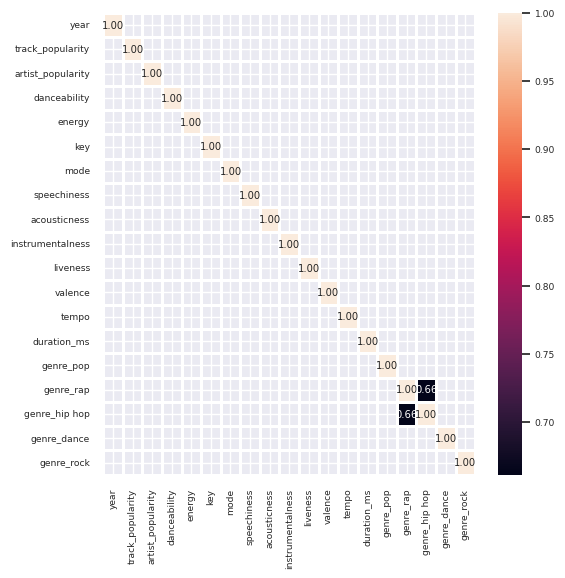

In [18]:
import seaborn as sns
import matplotlib.pyplot as plt


corr_matrix = df.corr()
sns.set_theme(font_scale=0.6)

high_corr = corr_matrix[abs(corr_matrix) > 0.6]
fig, ax = plt.subplots(figsize=(6,6))
sns.heatmap(high_corr, annot=True, fmt=".2f", linewidths=1, ax=ax)

# The only correlation we found above 0.6 was between hip-hop and rap, which we are using for profiling variables, so we do not need to discard these

# 2. Segmentation

### 2.1 Standardisation

In [19]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

array = scaler.fit_transform(df)
df = pd.DataFrame(scaler.fit_transform(df), columns=df.columns)

### 2.2 Elbow Method

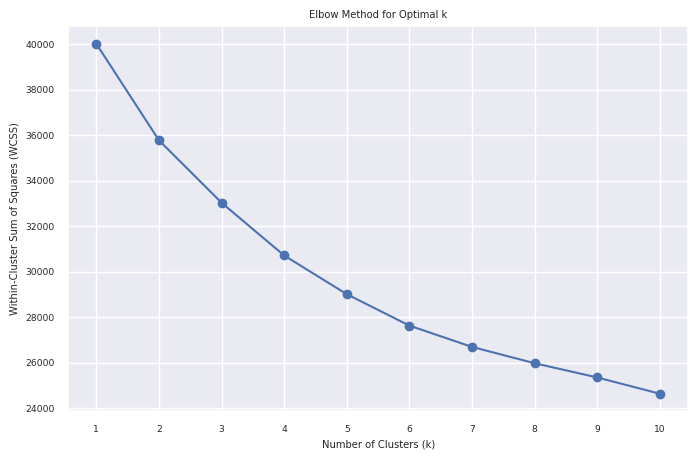

In [20]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

wcss = []
K_range = range(1, 11)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(df)
    wcss.append(kmeans.inertia_)


plt.figure(figsize=(8, 5))
plt.plot(K_range, wcss, marker='o', linestyle='-')
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Within-Cluster Sum of Squares (WCSS)")
plt.title("Elbow Method for Optimal k")
plt.xticks(K_range)
plt.grid(True)
plt.show()

### 2.3 Clustering Variable Selection

In [21]:
newCV.index

Index(['instrumentalness', 'acousticness', 'speechiness', 'liveness', 'key',
       'mode', 'valence', 'energy', 'tempo', 'danceability', 'duration_ms',
       'track_popularity', 'artist_popularity', 'year'],
      dtype='object')

In [22]:
print(newCV[0:7])

instrumentalness    6.271399
acousticness        1.313437
speechiness         0.934678
liveness            0.762658
key                 0.689853
mode                0.833437
valence             0.425268
dtype: float64


In [23]:
# Using the top 5 in terms of variance, we chose different combinations of 3 variables and checked the silhouette for each combo

top5variance = {'instrumentalness','acousticness','speechiness','liveness','valence'}

from itertools import chain, combinations

def powerset(iterable):
    s = list(iterable)
    return list(chain.from_iterable(combinations(s, r) for r in range(len(s) + 1)))[1:]

combos = powerset(top5variance)

combos3 = []

for combo in combos:
    if len(combo)==3:
        combos3.append(combo)

combos3

#We then had a list of all combinations of 3 from the list of 5 variables

[('instrumentalness', 'liveness', 'acousticness'),
 ('instrumentalness', 'liveness', 'valence'),
 ('instrumentalness', 'liveness', 'speechiness'),
 ('instrumentalness', 'acousticness', 'valence'),
 ('instrumentalness', 'acousticness', 'speechiness'),
 ('instrumentalness', 'valence', 'speechiness'),
 ('liveness', 'acousticness', 'valence'),
 ('liveness', 'acousticness', 'speechiness'),
 ('liveness', 'valence', 'speechiness'),
 ('acousticness', 'valence', 'speechiness')]

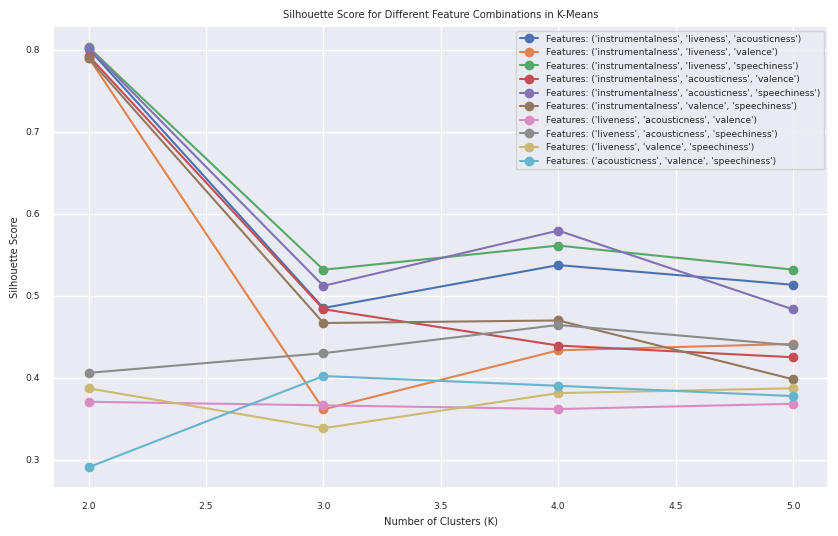

In [24]:
from sklearn.metrics import silhouette_score

k_values = range(2, 6)

silhouette_results = {}

for features in combos3:
    scores = []

    for k in k_values:
        kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
        labels = kmeans.fit_predict(df[list(features)])
        score = silhouette_score(df[list(features)], labels)
        scores.append(score)

    silhouette_results[features] = scores

plt.figure(figsize=(10, 6))

for features, scores in silhouette_results.items():
    plt.plot(k_values, scores, marker='o', label=f"Features: {features}")

plt.xlabel("Number of Clusters (K)")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Score for Different Feature Combinations in K-Means")
plt.legend()
plt.grid(True)
plt.show()

In [25]:
# Given the above graph, we decided to choose 'liveness', 'speechiness','instrumentalness' as our 3 clustering variables, with a k of 5

In [26]:
xValue = 'instrumentalness'
yValue = 'speechiness'
zValue = 'acousticness'

In [27]:
print(df[[xValue,yValue,zValue]].max())
print(df[[xValue,yValue,zValue]].min())

xMax = 3
yMax = 3
zMax = 3

xMin = 0
yMin = 0
zMin = 0

# We calculated the max and min for each axis to allow us to set a limit of where the centroids should be placed.

instrumentalness    12.041894
speechiness          5.025013
acousticness         4.072519
dtype: float64
instrumentalness   -0.159492
speechiness        -0.824642
acousticness       -0.761478
dtype: float64


### 2.3 Assignment Stage

In [28]:
print(f"xMin: {xMin}, xMax: {xMax}")
print(f"yMin: {yMin}, yMax: {yMax}")
print(f"zMin: {zMin}, zMax: {zMax}")

xMin: 0, xMax: 3
yMin: 0, yMax: 3
zMin: 0, zMax: 3


In [29]:
import numpy as np

# The Elbow Method above gave us a k value of 5
k = 5

np.random.seed()

'''centroids = {
    i+1: [np.random.uniform(xMin, xMax), np.random.uniform(yMin, yMax),np.random.uniform(zMin, zMax)]
    for i in range(k)
} '''

## Note - We executed the above code when first running the analysis, but saved the centroids below for consistency when re running the notebook

centroids = {1: [-0.14829956741542738, 0.8879777086532996, -0.22742480936800727],
 2: [-0.11071058627683035, -0.4630874026485636, 2.015420612852712],
 3: [8.109189487314264, -0.41845495961452756, -0.03955631888797129],
 4: [-0.1273516409357416, 2.5753408473164914, 0.05679265281153245],
 5: [-0.08973153367117621, -0.4806508129961853, -0.4019981907647515]}

colmap = colmap = {
    5: "blue",
    1: "green",
    2: "yellow",
    3: "red",
    4: "purple"
}

def assignment(df, centroids):
    for i in centroids.keys():
        df['distance_from_{}'.format(i)] = np.sqrt(
            (df[xValue] - centroids[i][0]) ** 2 +
            (df[yValue] - centroids[i][1]) ** 2 +
            (df[zValue] - centroids[i][2]) ** 2
        )

    centroid_distance_cols = ['distance_from_{}'.format(i) for i in centroids.keys()]

    df['Cluster'] = df.loc[:, centroid_distance_cols].idxmin(axis=1)
    df['Cluster'] = df['Cluster'].map(lambda x: int(x.lstrip('distance_from_')))

    df['color'] = df['Cluster'].map(lambda x: colmap.get(x, 'black'))

    return df

df = assignment(df, centroids)

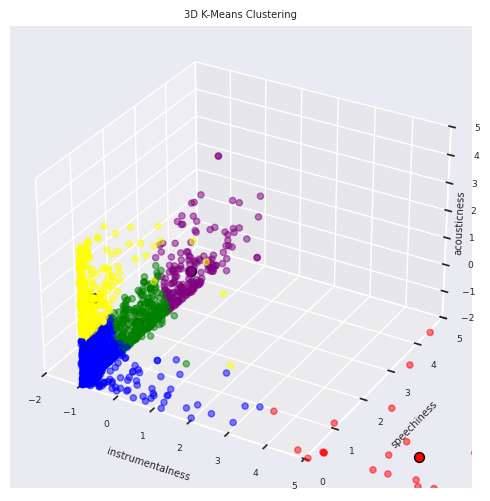

In [30]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

fig = plt.figure(figsize=(6, 6))
ax: Axes3D = fig.add_subplot(111, projection='3d')  # Type hinting

ax.scatter(df[xValue], df[yValue], df[zValue], color=df['color'], alpha=0.5, marker='o')

for i in centroids.keys():
    ax.scatter(*centroids[i], color=colmap[i], marker='o', s=50, edgecolors='black')

ax.set_xlim(-2, 5)
ax.set_ylim(0, 5)
ax.set_zlim(-2, 5)

ax.set_xlabel(f'{xValue}')
ax.set_ylabel(f'{yValue}')
ax.set_zlabel(f'{zValue}',labelpad=-15)

ax.set_title("3D K-Means Clustering")

plt.show()

### 2.4 Update stage

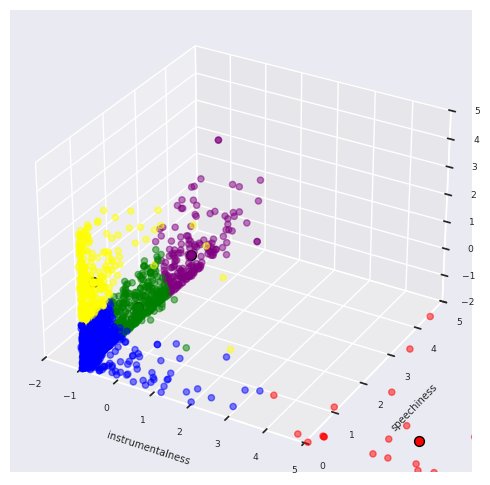

In [31]:
import copy

old_centroids = copy.deepcopy(centroids)

def update(k):
    for i in centroids.keys():
        centroids[i][0] = np.mean(df[df['Cluster'] == i][xValue])
        centroids[i][1] = np.mean(df[df['Cluster'] == i][yValue])
        centroids[i][2] = np.mean(df[df['Cluster'] == i][zValue])
    return k

centroids = update(centroids)

fig = plt.figure(figsize=(6, 6))
ax = fig.add_subplot(111, projection='3d')

ax.scatter(df[xValue], df[yValue], df[zValue], color=df['color'], alpha=0.5)

for i in centroids.keys():
    ax.scatter(*centroids[i], color=colmap[i], s=50, edgecolor='black')

ax.set_xlim(-2, 5)
ax.set_ylim(0, 5)
ax.set_zlim(-2, 5)

ax.set_xlabel(xValue)
ax.set_ylabel(yValue)
ax.set_zlabel(zValue)

plt.show()

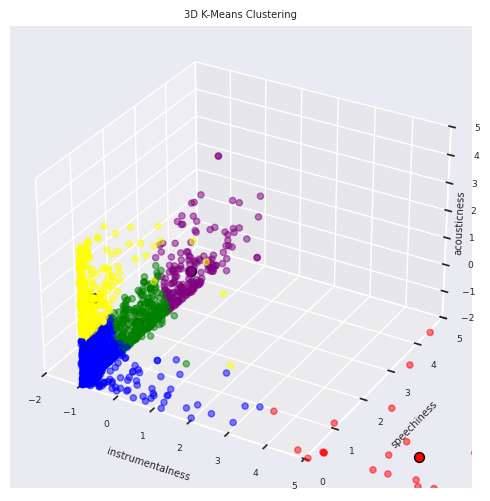

In [32]:
while True:
    closest_centroids = df['Cluster'].copy(deep=True)
    centroids = update(centroids)
    df = assignment(df, centroids)
    if closest_centroids.equals(df['Cluster']):
        break

fig = plt.figure(figsize=(6, 6))
ax: Axes3D = fig.add_subplot(111, projection='3d')  # Type hinting

ax.scatter(df[xValue], df[yValue], df[zValue], color=df['color'], alpha=0.5, marker='o')

for i in centroids.keys():
    ax.scatter(*centroids[i], color=colmap[i], marker='o', s=50, edgecolors='black')

ax.set_xlim(-2, 5)
ax.set_ylim(0, 5)
ax.set_zlim(-2, 5)

ax.set_xlabel(f'{xValue}')
ax.set_ylabel(f'{yValue}')
ax.set_zlabel(f'{zValue}',labelpad=-15)

ax.set_title("3D K-Means Clustering")

plt.show()

In [33]:
clustersizes = df.groupby('Cluster')['key'].count()
clustersizes

# We obtained the size of each cluster, seeing that there is a large discrepancy in the size of the clusters, with the vast majority belonging to cluster 1

,key
Cluster,
1,335
2,288
3,27
4,179
5,1277


### 2.5 Silhouette

In [34]:
from sklearn.metrics import silhouette_score

silhouette_avg = silhouette_score(df[[xValue,yValue,zValue]], df['Cluster'])

f'Silhouette score = {round(silhouette_avg,3)}'


'Silhouette score = 0.492'

### 2.6 Labelling/Profiling

In [35]:
df['Cluster'] = df['Cluster'].apply(int)

In [36]:
import pandas as pd

X = df.iloc[:, :-1] # numerical only

df_prof = X.groupby("Cluster").mean().transpose()
df_prof = df_prof[:-5]
df_prof["Average"] = df_prof.mean(axis=1)
df_prof["Std.dev"] = df_prof.std(axis=1)

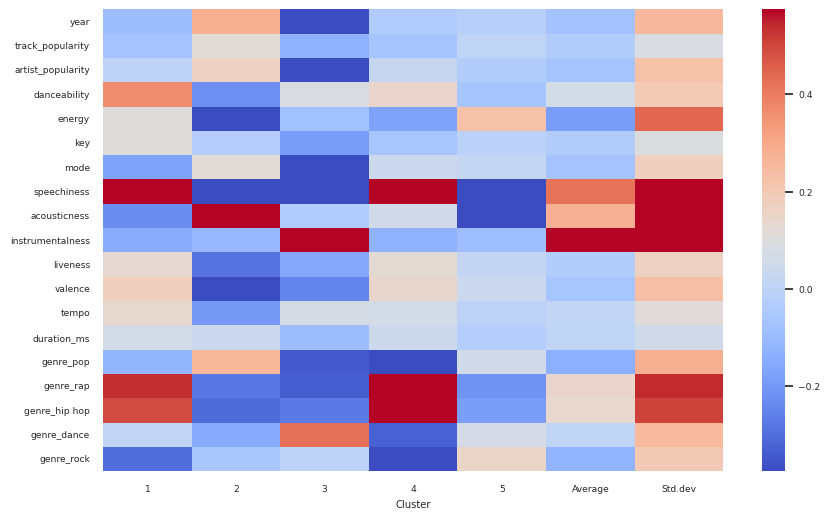

In [37]:
# When producing this chart first, we could not see much variation in colour, so we set the colour scale to 5th and 95th percentiles to accentuate the variation

vmin = np.percentile(df_prof, 7.5)  # Set lower bound at 5th percentile
vmax = np.percentile(df_prof, 92.5) # Set upper bound at 93rd percentile

plt.figure(figsize=(10, 6))
sns.heatmap(df_prof, cmap="coolwarm", vmin=vmin, vmax=vmax,annot=False, cbar=True)
plt.show()

### 2.7 Validation

In [38]:
# We paired the song names back with the cluster solution

checker = songsDF[['track_name','artist_name']].join(df['Cluster'])
checker = checker[~checker['Cluster'].isna()]
checker

,track_name,artist_name,Cluster
1,Absolutely (Story of a Girl) - Radio Mix,Nine Days,2.0
2,Against All Odds (Take A Look at Me Now) - Mar...,Mariah Carey,5.0
3,All The Small Things,blink-182,5.0
7,Be Like That,3 Doors Down,3.0
8,Be With You,Enrique Iglesias,1.0
...,...,...,...
2101,"34+35 Remix (feat, Doja Cat; Megan Thee Stalli...",Ariana Grande,4.0
2102,Afterglow,Ed Sheeran,5.0
2103,All Too Well (10 Minute Version) (Taylor's Ver...,Taylor Swift,2.0
2104,Anyone,Justin Bieber,5.0


In [39]:
# We then took a selection of 5 songs from each cluster to validate against our own knowledge of music

checker[checker['Cluster']==2].sample(5)

sampleDF = []

for cluster in range(6):
    counter = 0
    for i, song in checker.iterrows():
        if (song['Cluster']==cluster) & (counter < 5):
            counter +=1
            sampleDF.append(song)

sampleDF = pd.DataFrame(sampleDF)

sampleDF

,track_name,artist_name,Cluster
8,Be With You,Enrique Iglesias,1.0
13,Born to Make You Happy,Britney Spears,1.0
24,Desert Rose,Sting,1.0
61,Never Be The Same Again,Melanie C,1.0
74,Shalala Lala,Vengaboys,1.0
1,Absolutely (Story of a Girl) - Radio Mix,Nine Days,2.0
27,Don't Think I'm Not,Kandi,2.0
59,Music,Madonna,2.0
78,Take A Picture,Filter,2.0
87,There You Go,P!nk,2.0


In [40]:
# We exported the sample of songs for inclusion in the report annexes

sampleDF.to_excel('sampleSongs.xlsx')

# 3. Linear Regression

### 3.1 Importing Libraries

In [41]:
import statsmodels.api as sm                    # Statistical analysis
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from scipy import stats

import warnings                              # Disable some warnings
warnings.filterwarnings("ignore",category=DeprecationWarning)

### 3.2 Data Exploration

In [42]:
columns_for_linear_regression = [
    'year', 'track_popularity', 'artist_popularity', 'danceability',
    'energy', 'key', 'mode', 'speechiness', 'acousticness',
    'instrumentalness', 'liveness', 'valence', 'tempo', 'duration_ms'
]

df = df[columns_for_linear_regression]
# To remove segmentation specific-variables

In [43]:
pd.set_option("display.precision", 2)
df.describe()

,year,track_popularity,artist_popularity,danceability,energy,key,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,duration_ms
count,2.11e+03,2.11e+03,2.11e+03,2.11e+03,2.11e+03,2.11e+03,2.11e+03,2.11e+03,2.11e+03,2.11e+03,2.11e+03,2.11e+03,2.11e+03,2.11e+03
mean,8.80e-15,-5.13e-16,3.51e-16,3.17e-16,5.53e-16,8.77e-17,-7.68e-17,4.89e-17,1.35e-17,-3.37e-18,-9.45e-17,3.91e-16,2.70e-16,-2.16e-16
std,1.00e+00,1.00e+00,1.00e+00,1.00e+00,1.00e+00,1.00e+00,1.00e+00,1.00e+00,1.00e+00,1.00e+00,1.00e+00,1.00e+00,1.00e+00,1.00e+00
min,-1.75e+00,-5.81e+00,-3.72e+00,-3.59e+00,-3.95e+00,-1.45e+00,-1.20e+00,-8.25e-01,-7.61e-01,-1.59e-01,-1.15e+00,-2.19e+00,-2.20e+00,-2.66e+00
25%,-8.27e-01,-4.41e-01,-6.12e-01,-6.20e-01,-6.47e-01,-9.02e-01,-1.20e+00,-6.52e-01,-6.82e-01,-1.59e-01,-6.25e-01,-7.65e-01,-7.95e-01,-6.11e-01
50%,9.37e-02,1.29e-01,7.82e-02,7.15e-02,1.09e-01,-7.89e-02,8.33e-01,-4.47e-01,-4.35e-01,-1.59e-01,-4.05e-01,1.88e-02,-2.00e-02,-1.05e-01
75%,8.61e-01,6.18e-01,7.69e-01,6.98e-01,7.63e-01,7.44e-01,8.33e-01,2.21e-01,2.86e-01,-1.59e-01,3.47e-01,8.24e-01,6.32e-01,4.83e-01
max,1.63e+00,2.33e+00,2.24e+00,2.23e+00,1.87e+00,1.57e+00,8.33e-01,5.03e+00,4.07e+00,1.20e+01,5.08e+00,1.94e+00,3.29e+00,1.09e+01


In [44]:
# Check for missing values
missing_values = df.isnull().sum()
missing_values

,0
year,0
track_popularity,0
artist_popularity,0
danceability,0
energy,0
key,0
mode,0
speechiness,0
acousticness,0
instrumentalness,0


[Text(0.5, 1.0, 'Histogram of track_popularity variable')]

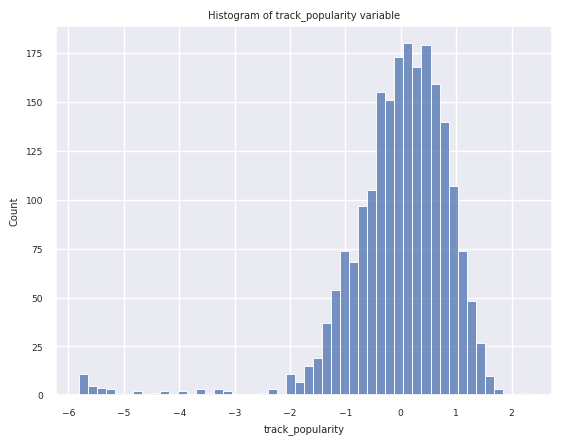

In [45]:
# Histogram of dependent variable
target = "track_popularity"
sns.histplot(df[target]).set(title='Histogram of track_popularity variable')

### 3.3 Data Reservation for Prediction

In [46]:
# model = 90%
# reserved = 10%

df_model, df_reserved = train_test_split(df, test_size=0.1, random_state=42)

print("Sample size dataset reserved for prediction: ", df_reserved.shape[0], "records")

target = 'track_popularity'
y = df_model[target]

Sample size dataset reserved for prediction:  211 records


### 3.4 Train Test Split

In [47]:
# cross validation (80%-20%)
X = df_model
y = df_model['track_popularity']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Sample size train dataset: ", X_train.shape)
print("Sample size test dataset: ", X_test.shape)

Sample size train dataset:  (1516, 14)
Sample size test dataset:  (379, 14)


### 3.5 Stepwise Execution

In [48]:
# Stepwise function
def stepwise_selection(X, y,
                       initial_list=[],
                       threshold_in=0.05,
                       threshold_out = 0.1,
                       verbose=True):
    """ Perform a forward-backward feature selection
    based on p-value from statsmodels.api.OLS
    Arguments:
        X - pandas.DataFrame with candidate features
        y - list-like with the target
        initial_list - list of features to start with (column names of X)
        threshold_in - include a feature if its p-value < threshold_in
        threshold_out - exclude a feature if its p-value > threshold_out
        verbose - whether to print the sequence of inclusions and exclusions
    Returns: list of selected features
    Always set threshold_in < threshold_out to avoid infinite looping.
    """
    included = list(initial_list)
    while True:
        changed=False
        # forward step
        excluded = list(set(X.columns)-set(included))
        new_pval = pd.Series(index=excluded)
        for new_column in excluded:
            model = sm.OLS(y, sm.add_constant(X[included+[new_column]])).fit()
            new_pval[new_column] = model.pvalues[new_column]
        best_pval = new_pval.min()
        if best_pval < threshold_in:
            best_feature = new_pval.idxmin()
            included.append(best_feature)
            changed=True
            if verbose:
                print('Add  {:30} with p-value {:.4}'.format(best_feature, best_pval))

        # backward step
        model = sm.OLS(y, sm.add_constant(X[included])).fit()
        # use all coefs except intercept
        pvalues = model.pvalues.iloc[1:]
        worst_pval = pvalues.max() # null if pvalues is empty
        if worst_pval > threshold_out:
            changed=True
            worst_feature = pvalues.argmax()
            included.remove(worst_feature)
            if verbose:
                print('Drop {:30} with p-value {:.4}'.format(worst_feature, worst_pval))
        if not changed:
            break
    return included

In [49]:
# Removes some variables: target, irrelevent and those with missing values (stepwise does not work with them)
# we will call X_train2 to this dataframe

irrelevant_columns = [target]
X_train2=X_train.drop(columns=irrelevant_columns)

for field in X_train2:
    if X_train2[field].isnull().any():
        X_train2=X_train2.drop(labels=[field], axis=1)

X_train2

,year,artist_popularity,danceability,energy,key,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,duration_ms
2097,1.63,1.20,-1.80,-2.82,-0.35,-1.20,-0.67,3.34,-0.08,-0.20,-1.83,0.72,1.31
1141,0.25,2.24,-0.02,0.21,0.47,0.83,-0.67,-0.75,-0.14,-0.95,0.59,-0.60,0.15
208,-1.44,-1.48,0.68,0.45,0.20,0.83,0.77,-0.64,-0.16,-0.24,1.28,-1.37,-0.50
85,-1.59,-1.22,1.10,-0.67,-0.08,0.83,-0.75,1.41,-0.16,-0.20,1.68,-0.57,-0.17
377,-1.13,-1.56,0.73,0.78,-0.35,-1.20,0.87,-0.31,-0.16,0.33,1.89,1.53,1.21
...,...,...,...,...,...,...,...,...,...,...,...,...,...
731,-0.52,-0.35,0.05,0.43,1.57,0.83,2.65,-0.40,-0.16,-0.88,-0.66,1.00,2.25
728,-0.52,-0.96,-0.58,0.56,-0.90,-1.20,-0.75,-0.66,-0.16,0.11,0.17,0.09,0.78
910,-0.21,-0.96,-1.64,0.87,-0.63,0.83,3.68,-0.73,-0.16,-0.42,1.08,0.16,-0.21
2064,1.63,1.72,1.01,-0.13,-0.08,-1.20,-0.72,0.69,-0.16,-0.44,-1.07,-0.75,0.48


### 3.6 Chosen Explanatory Variables

In [50]:
# Stepwise selection to select relevant features
result = stepwise_selection(X_train2, y_train)
print("Selected features: ", result)


Add  artist_popularity              with p-value 4.083e-32
Add  year                           with p-value 0.000381
Add  speechiness                    with p-value 0.003772
Selected features:  ['artist_popularity', 'year', 'speechiness']


In [51]:
# Create a new dataframe with the selected explanatory variables
X_train_stepwise = X_train2.copy()  # Create a copy of the training dataset

# Iterate over all the columns in the training set
for item in X_train2.columns:
    # If the feature is not in the selected result (from stepwise selection)
    if item not in result:
        X_train_stepwise = X_train_stepwise.drop(labels=[item], axis=1)  # Drop the feature


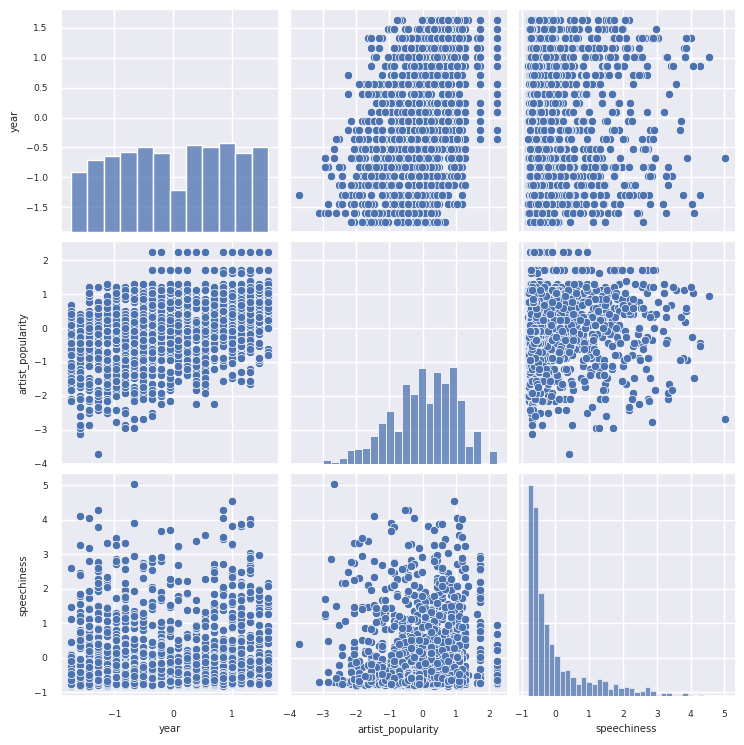

In [52]:
sns.pairplot(X_train_stepwise)

<Axes: >

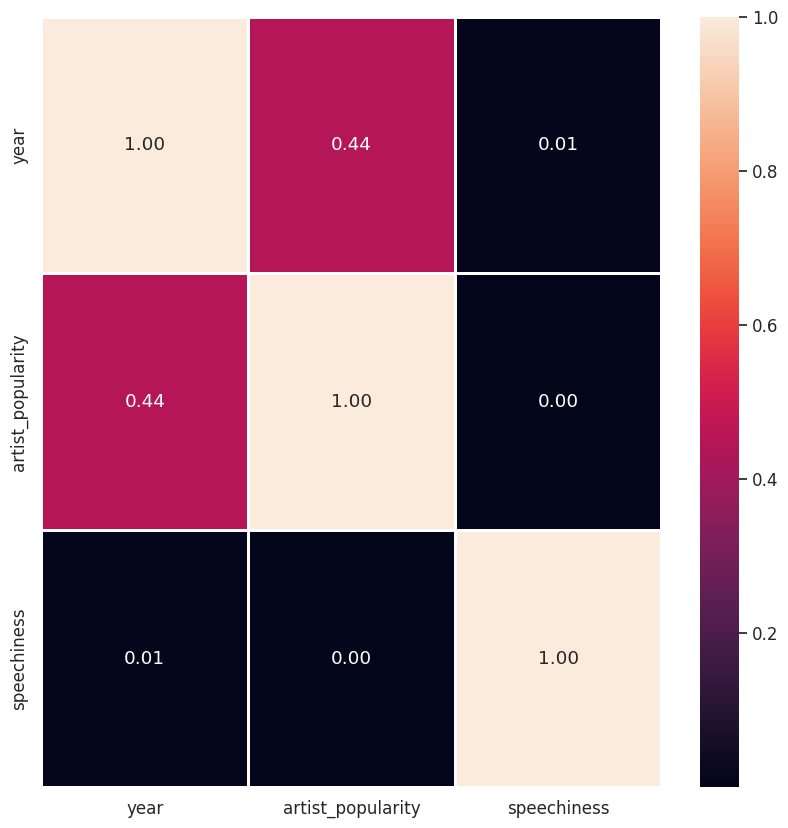

In [53]:
# and heatmap to show correlation between explanatory variables
sns.set(font_scale=1.1)
fig, ax = plt.subplots(figsize=(10,10))
sns.heatmap(X_train_stepwise.corr(), annot=True, fmt=".2f", linewidths=1, ax=ax)

### 3.7 Creating and Training the Model

In [54]:
lm = LinearRegression(fit_intercept=True)
model=lm.fit(X_train_stepwise, y_train)

Model Evaluation

In [55]:
# print R squared train dataset
r_squared = model.score(X_train_stepwise, y_train)
print(f"R squared value is : {r_squared:.3f}")

R squared value is : 0.100


In [56]:
# print coefficients (but not confidence intervals: sklearn does not store them)
coeff_df = pd.DataFrame(model.coef_, X_train_stepwise.columns, columns=['Coefficient'])
print("Intercept:", lm.intercept_)
print(coeff_df)

Intercept: 0.004170948823303091
                   Coefficient
year                      0.10
artist_popularity         0.25
speechiness              -0.07


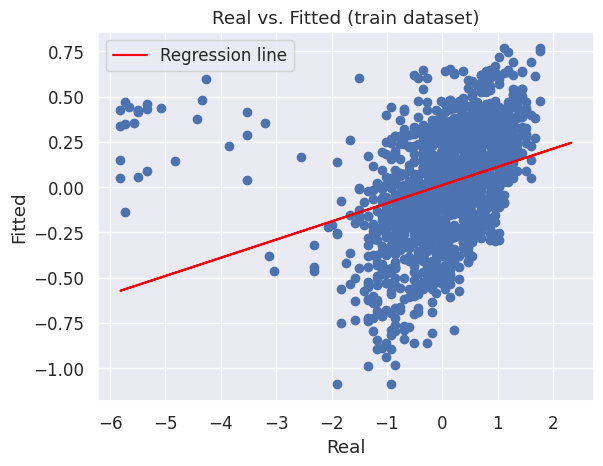

In [57]:
predictions_train = lm.predict(X_train[X_train_stepwise.columns]) #only with the columns used in the model

plt.title("Real vs. Fitted (train dataset)")
plt.scatter(y_train,predictions_train)

coef = np.polyfit(y_train, predictions_train, 1)
poly1d_fn = np.poly1d(coef)
plt.plot(y, poly1d_fn(y), color="red", label="Regression line")

plt.xlabel("Real")
plt.ylabel("Fitted")
plt.legend()
plt.show()

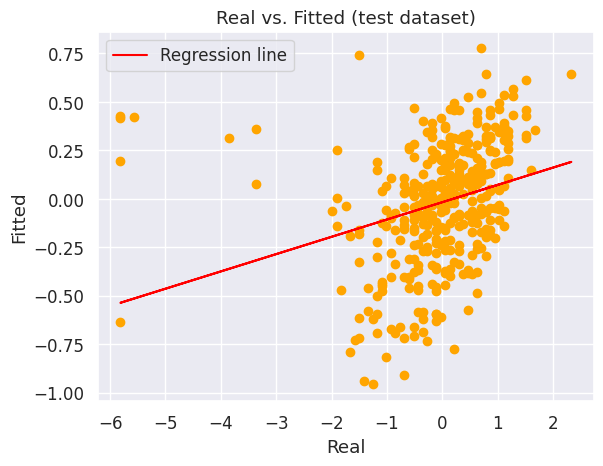

In [58]:
# test dataset
predictions_test = lm.predict(X_test[X_train_stepwise.columns]) #only with the columns used in the model
plt.title("Real vs. Fitted (test dataset)")
plt.scatter(y_test,predictions_test, color="orange")

coef = np.polyfit(y_test, predictions_test, 1)
poly1d_fn = np.poly1d(coef)
plt.plot(y_test, poly1d_fn(y_test), color="red", label="Regression line")

plt.xlabel("Real")
plt.ylabel("Fitted")

plt.legend()
plt.show()

[Text(0.5, 1.0, 'Histogram of dependent - train dataset')]

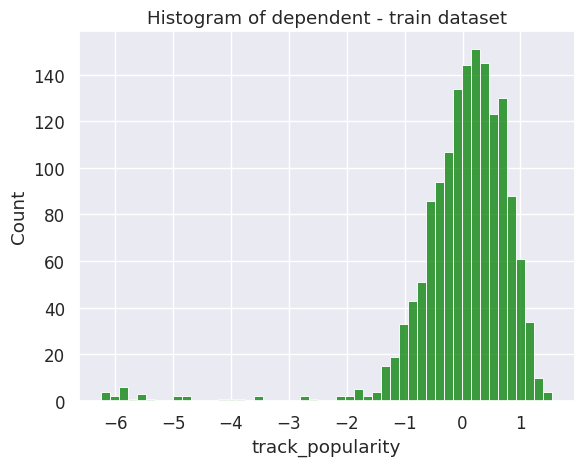

In [59]:
# training dataset
sns.histplot((y_train-predictions_train),bins=50, color="green").set(title='Histogram of dependent - train dataset')

[Text(0.5, 1.0, 'Histogram of dependent - test dataset')]

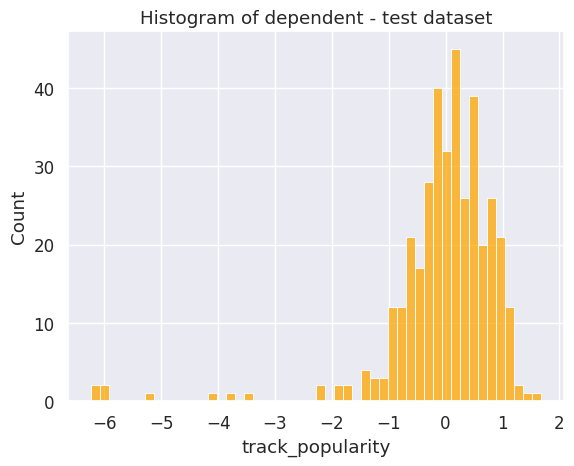

In [60]:
# test dataset
sns.histplot((y_test-predictions_test),bins=50, color="orange").set(title='Histogram of dependent - test dataset')

### 3.8 Evaluation Metrics

In [61]:
from sklearn import metrics

# error comparison between the two datasets
print ("Errors:\n")
results = {
    'Metric': ['MAE', 'MSE', 'RMSE', 'MAPE %'],
    'Train': [
        metrics.mean_absolute_error(y_train, predictions_train),
        metrics.mean_squared_error(y_train, predictions_train),
        np.sqrt(metrics.mean_squared_error(y_train, predictions_train)),
        np.mean(100 * abs(y_train - predictions_train) / y_train)
    ],
    'Test': [
        metrics.mean_absolute_error(y_test, predictions_test),
        metrics.mean_squared_error(y_test, predictions_test),
        np.sqrt(metrics.mean_squared_error(y_test, predictions_test)),
        np.mean(100 * abs(y_test - predictions_test) / y_test)
    ]
}

results_df = pd.DataFrame(results)
results_df

Errors:



,Metric,Train,Test
0,MAE,0.59,0.61
1,MSE,0.88,0.99
2,RMSE,0.94,0.99
3,MAPE %,6.21,9.43


### 3.9 Results

In [62]:
# model with an additional library (statmodels)
X_train_stepwise = sm.add_constant(X_train_stepwise)

In [63]:
result = sm.OLS(y_train, X_train_stepwise).fit()
print (result.summary())

                            OLS Regression Results                            
Dep. Variable:       track_popularity   R-squared:                       0.100
Model:                            OLS   Adj. R-squared:                  0.099
Method:                 Least Squares   F-statistic:                     56.27
Date:                Sun, 23 Feb 2025   Prob (F-statistic):           1.76e-34
Time:                        11:19:19   Log-Likelihood:                -2056.0
No. Observations:                1516   AIC:                             4120.
Df Residuals:                    1512   BIC:                             4141.
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                        coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------
const                 0.0042      0.02